ESTRUTURA INICIAL


In [ ]:
import pandas as pd

visits = pd.read_csv('visits.csv')
transactions = pd.read_csv('transactions.csv')
url_params = pd.read_csv('url_params.csv')
visit_url_metadata = pd.read_csv('visit_url_metadata.csv')
partners = pd.read_csv('partners.csv')
channels = pd.read_csv('channels.csv')

Criar overview automático das tabelas

In [ ]:
datasets = {
    'visits': visits,
    'transactions': transactions,
    'url_params': url_params,
    'visit_url_metadata': visit_url_metadata,
    'partners': partners,
    'channels': channels
}

for name, df in datasets.items():
    print(f'\n{"="*60}')
    print(f'TABELA: {name.upper()}')
    print(f'{"="*60}')

    print(f'Shape: {df.shape}')

    print('\nTipos:')
    print(df.dtypes)

    print('\nMissing values:')
    print(df.isnull().sum())

    print('\nDuplicados:')
    print(df.duplicated().sum())


TABELA: VISITS
Shape: (1197465, 6)

Tipos:
visit_id        object
visit_at_brt    object
customer_id     object
partner_id      object
channel_id      object
url_param_id    object
dtype: object

Missing values:
visit_id        0
visit_at_brt    0
customer_id     0
partner_id      0
channel_id      0
url_param_id    0
dtype: int64

Duplicados:
0

TABELA: TRANSACTIONS
Shape: (160269, 7)

Tipos:
transaction_id                 object
visit_id                       object
customer_id                    object
purchased_at_brt               object
sale_amount                   float64
cashback_amount               float64
expected_commission_amount    float64
dtype: object

Missing values:
transaction_id                0
visit_id                      0
customer_id                   0
purchased_at_brt              0
sale_amount                   0
cashback_amount               0
expected_commission_amount    0
dtype: int64

Duplicados:
0

TABELA: URL_PARAMS
Shape: (56506, 3)

Tipos:
url_par

Explorar


In [ ]:
print(url_params.columns.tolist())

print(visit_url_metadata.columns.tolist())

print(visits.columns.tolist())

print(channels.columns.tolist())

['url_param_id', 'utm_content', 'utm_term']
['visit_id', 'tracking_url_params']
['visit_id', 'visit_at_brt', 'customer_id', 'partner_id', 'channel_id', 'url_param_id']
['channel_id', 'channel_name']


In [ ]:
visit_url_metadata.head(3)

,visit_id,tracking_url_params
0,7a9372b4d6059f2fee04894510228345bd9cc97e854af3...,"{""mz_test_gotoexternalbrowser"":""a"",""mz_redirec..."
1,2f1bd3fda7116696ec2d84d202aef7d5f2d36bc2c2d8e1...,"{""mz_test_gotoexternalbrowser"":""a"",""mz_redirec..."
2,968fbf6009b0ae8c244370a4d1c84868ae1580f01c813a...,"{""mz_test_gotoexternalbrowser"":""a"",""mz_redirec..."


DATA PROFILING & VALIDATION


In [ ]:


datasets = {
    'visits': visits,
    'transactions': transactions,
    'url_params': url_params,
    'visit_url_metadata': visit_url_metadata,
    'partners': partners,
    'channels': channels
}

profiling_summary = []

for table_name, df in datasets.items():

    print(f'\n{"="*80}')
    print(f'TABELA: {table_name.upper()}')
    print(f'{"="*80}')

    print(f'\nShape: {df.shape}')

    print('\nTipos das colunas:')
    print(df.dtypes)

    print('\nMissing values:')
    missing = df.isnull().sum()
    print(missing[missing > 0].sort_values(ascending=False))

    print('\nDuplicados totais:')
    print(df.duplicated().sum())

    profiling_summary.append({
        'table': table_name,
        'rows': df.shape[0],
        'columns': df.shape[1],
        'total_missing': df.isnull().sum().sum(),
        'duplicated_rows': df.duplicated().sum()
    })

# summary final
profiling_summary = pd.DataFrame(profiling_summary)

print('\n')
print('='*80)
print('PROFILING SUMMARY')
print('='*80)

profiling_summary


TABELA: VISITS

Shape: (1197465, 6)

Tipos das colunas:
visit_id        object
visit_at_brt    object
customer_id     object
partner_id      object
channel_id      object
url_param_id    object
dtype: object

Missing values:
Series([], dtype: int64)

Duplicados totais:
0

TABELA: TRANSACTIONS

Shape: (160269, 7)

Tipos das colunas:
transaction_id                 object
visit_id                       object
customer_id                    object
purchased_at_brt               object
sale_amount                   float64
cashback_amount               float64
expected_commission_amount    float64
dtype: object

Missing values:
Series([], dtype: int64)

Duplicados totais:
0

TABELA: URL_PARAMS

Shape: (56506, 3)

Tipos das colunas:
url_param_id    object
utm_content     object
utm_term        object
dtype: object

Missing values:
utm_term    56461
dtype: int64

Duplicados totais:
0

TABELA: VISIT_URL_METADATA

Shape: (1197465, 2)

Tipos das colunas:
visit_id               object
tracking_u

,table,rows,columns,total_missing,duplicated_rows
0,visits,1197465,6,0,0
1,transactions,160269,7,0,0
2,url_params,56506,3,56461,0
3,visit_url_metadata,1197465,2,0,0
4,partners,435,2,0,0
5,channels,2,2,0,0


KEY VALIDATION

In [ ]:
key_columns = {
    'visits': ['visit_id', 'partner_id', 'channel_id', 'url_param_id'],
    'transactions': ['transaction_id', 'visit_id'],
    'url_params': ['url_param_id'],
    'visit_url_metadata': ['visit_id'],
    'partners': ['partner_id'],
    'channels': ['channel_id']
}

for table_name, cols in key_columns.items():

    df = datasets[table_name]

    print(f'\n{"="*80}')
    print(f'KEY VALIDATION: {table_name.upper()}')
    print(f'{"="*80}')

    for col in cols:

        if col in df.columns:

            print(f'\nCOLUNA: {col}')

            print(f'- missing: {df[col].isnull().sum()}')
            print(f'- unique: {df[col].nunique()}')
            print(f'- duplicated: {df[col].duplicated().sum()}')


KEY VALIDATION: VISITS

COLUNA: visit_id
- missing: 0
- unique: 1197465
- duplicated: 0

COLUNA: partner_id
- missing: 0
- unique: 435
- duplicated: 1197030

COLUNA: channel_id
- missing: 0
- unique: 2
- duplicated: 1197463

COLUNA: url_param_id
- missing: 0
- unique: 56506
- duplicated: 1140959

KEY VALIDATION: TRANSACTIONS

COLUNA: transaction_id
- missing: 0
- unique: 160269
- duplicated: 0

COLUNA: visit_id
- missing: 0
- unique: 153531
- duplicated: 6738

KEY VALIDATION: URL_PARAMS

COLUNA: url_param_id
- missing: 0
- unique: 56506
- duplicated: 0

KEY VALIDATION: VISIT_URL_METADATA

COLUNA: visit_id
- missing: 0
- unique: 1197465
- duplicated: 0

KEY VALIDATION: PARTNERS

COLUNA: partner_id
- missing: 0
- unique: 435
- duplicated: 0

KEY VALIDATION: CHANNELS

COLUNA: channel_id
- missing: 0
- unique: 2
- duplicated: 0


# Regras Analíticas e Observações

## Regras do enunciado consideradas

- `utm_content` deve ser lido via `url_params`
- `utm_term` deve ser lido via `url_params`
- variantes A/B/C devem ser identificadas via `visit_url_metadata`
- `mz_*` não devem ser inferidos fora do JSON
- parceiro deve ser identificado via `partner_id`
- compras atribuídas devem ser relacionadas via `transactions.visit_id`
- uma mesma `visit_id` pode possuir múltiplas compras
- joins devem respeitar granularidade
- métricas de conversão não podem assumir relação 1:1 entre visits e transactions

JSON EXTRACTION & VALIDATION


In [ ]:
import json

# visualizar exemplo do JSON
print('='*80)
print('EXEMPLO DE TRACKING_URL_PARAMS')
print('='*80)

print(
    visit_url_metadata['tracking_url_params']
    .dropna()
    .iloc[0]
)

EXEMPLO DE TRACKING_URL_PARAMS
{"mz_test_gotoexternalbrowser":"a","mz_redirect":"inapp"}


SAFE JSON PARSING

In [ ]:
def safe_json_parser(value):

    if pd.isnull(value):
        return {}

    try:
        if isinstance(value, dict):
            return value

        return json.loads(value)

    except Exception:
        return {}

# parse seguro
visit_url_metadata['tracking_params_dict'] = (
    visit_url_metadata['tracking_url_params']
    .apply(safe_json_parser)
)

print('JSON parsing concluído.')

JSON parsing concluído.


TRACKING FIELD EXTRACTION

In [ ]:
visit_url_metadata['variant'] = (
    visit_url_metadata['tracking_params_dict']
    .apply(lambda x: x.get('mz_test_gotoexternalbrowser'))
)

visit_url_metadata['mz_redirect'] = (
    visit_url_metadata['tracking_params_dict']
    .apply(lambda x: x.get('mz_redirect'))
)

print('='*80)
print('VARIANTES IDENTIFICADAS')
print('='*80)

print(
    visit_url_metadata['variant']
    .value_counts(dropna=False)
)

print('\n')

print('='*80)
print('REDIRECTS IDENTIFICADOS')
print('='*80)

print(
    visit_url_metadata['mz_redirect']
    .value_counts(dropna=False)
)

VARIANTES IDENTIFICADAS
variant
b       385757
c       383870
a       377716
None     50122
Name: count, dtype: int64


REDIRECTS IDENTIFICADOS
mz_redirect
inapp             1180701
browserdefault      16764
Name: count, dtype: int64


# Observações sobre variantes experimentais

## Variantes identificadas

As variantes A, B e C foram corretamente identificadas através do campo:
`visit_url_metadata.tracking_url_params.mz_test_gotoexternalbrowser`

## Observações importantes

Foi identificado um volume relevante de registros sem variante (`None`).

Possíveis hipóteses:
- eventos fora do escopo experimental
- falhas de instrumentação
- metadata ausente
- tráfego legacy
- inconsistências de tracking

Esses registros devem ser tratados antes da análise final do experimento para evitar viés analítico.

JOIN VISITS + URL PARAMS + METADATA

In [ ]:
experiment_base = (
    visits
    .merge(
        url_params,
        on='url_param_id',
        how='left'
    )
    .merge(
        visit_url_metadata[
            [
                'visit_id',
                'variant',
                'mz_redirect'
            ]
        ],
        on='visit_id',
        how='left'
    )
)

print(experiment_base.shape)

experiment_base.head()

(1197465, 10)


,visit_id,visit_at_brt,customer_id,partner_id,channel_id,url_param_id,utm_content,utm_term,variant,mz_redirect
0,c98e703fb13e0889de6cd49792a0f8bfea6b337b0d2dec...,2025-12-11 15:00:04,c50fd23128adb8dbdd1feedda1e946e92c0257bc32ffd3...,P294,C002,87af97a962c606176cb163c171cc917e3e2aa7e7e5c870...,PARTNER_PAGE,NaN,a,inapp
1,0d3c2b88ec70a0909db6e26b240c63a18025c0f7e4c125...,2025-12-11 15:00:05,4382b62397ded286348a4668edf8748ded759c6eea4a89...,P111,C002,dbdda26e389d947ce170f6969120ce07b8d54f90b698c9...,PARTNER_PAGE,NaN,a,inapp
2,b2712c2121d7857b977382a5f1c94629111d8935694b6f...,2025-12-11 15:00:06,57ffb406e5df0c581fde114c29be895b5c7b8627c33bee...,P113,C002,f7412307c5dec0a6b1385c0eaf666d0d77f2cb6ca0a296...,PARTNER_PAGE,NaN,b,inapp
3,cf7151a0225abe4e664a60e8e7c2c5d2ba1dd586ec7927...,2025-12-11 15:00:06,43449d627399684cda5b584e8f4a473e236b522fd073cd...,P153,C002,81c486154da3d1c2af0230810d4cf6a78ba7da5f208fc4...,PARTNER_PAGE,NaN,c,inapp
4,7495c6d7068f963d02e16e109d25571e77574cc6bf210a...,2025-12-11 15:00:07,87b31363e1c94913b1c76d8cba91878e933c381c66bbac...,P040,C002,ae5c70577ab844a008ccb1b173347d607e81a78902dc70...,PARTNER_PAGE,NaN,a,inapp


In [ ]:
experiment_base[
    [
        'variant',
        'utm_content',
        'utm_term',
        'mz_redirect'
    ]
].sample(10)

,variant,utm_content,utm_term,mz_redirect
1183206,c,PARTNER_PAGE,NaN,inapp
72427,a,PARTNER_PAGE,NaN,inapp
148115,c,PARTNER_PAGE,NaN,inapp
700886,b,PARTNER_PAGE,NaN,inapp
963470,c,PARTNER_PAGE,NaN,inapp
598210,c,PARTNER_PAGE,NaN,inapp
18699,b,PARTNER_PAGE,NaN,inapp
1177752,b,PARTNER_PAGE,NaN,inapp
102984,a,PARTNER_PAGE,NaN,inapp
155947,c,PARTNER_PAGE,NaN,inapp



FLOW RECONSTRUCTION


In [ ]:
experiment_base['flow_type'] = 'UNKNOWN'

# fluxo padrão In-App
experiment_base.loc[
    (
        (experiment_base['utm_content'] == 'PARTNER_PAGE') &
        (experiment_base['mz_redirect'] == 'inapp')
    ),
    'flow_type'
] = 'INAPP_DEFAULT'

# saída externa via header
experiment_base.loc[
    (
        (experiment_base['utm_content'] == 'EXTERNAL_BROWSER_MODAL') &
        (experiment_base['utm_term'] == 'HEADER')
    ),
    'flow_type'
] = 'EXTERNAL_HEADER'

# saída externa via login
experiment_base.loc[
    (
        (experiment_base['utm_content'] == 'EXTERNAL_BROWSER_MODAL') &
        (experiment_base['utm_term'] == 'LOGIN')
    ),
    'flow_type'
] = 'EXTERNAL_LOGIN'

# saída externa via config
experiment_base.loc[
    (
        (experiment_base['utm_content'] == 'EXTERNAL_BROWSER_MODAL') &
        (experiment_base['utm_term'] == 'CONFIG')
    ),
    'flow_type'
] = 'EXTERNAL_CONFIG'

print('='*80)
print('FLOW TYPES')
print('='*80)

print(
    experiment_base['flow_type']
    .value_counts(dropna=False)
)

FLOW TYPES
flow_type
INAPP_DEFAULT      1180701
EXTERNAL_LOGIN        6996
EXTERNAL_HEADER       5872
EXTERNAL_CONFIG       3896
Name: count, dtype: int64


In [ ]:
experiment_base[
    experiment_base['mz_redirect'] == 'browserdefault'
][
    [
        'utm_content',
        'utm_term',
        'variant',
        'mz_redirect'
    ]
].drop_duplicates().head(20)

,utm_content,utm_term,variant,mz_redirect
300,EXTERNAL_BROWSER_MODAL,HEADER,b,browserdefault
589,EXTERNAL_BROWSER_MODAL,LOGIN,b,browserdefault
743,EXTERNAL_BROWSER_MODAL,CONFIG,c,browserdefault
1373,EXTERNAL_BROWSER_MODAL,LOGIN,c,browserdefault


In [ ]:
# ============================================================
# TRANSACTIONS EXPLORATION
# ============================================================

print('='*80)
print('TRANSACTIONS COLUMNS')
print('='*80)

print(transactions.columns.tolist())

print('\n')

print('='*80)
print('TRANSACTIONS SAMPLE')
print('='*80)

transactions.head()

TRANSACTIONS COLUMNS
['transaction_id', 'visit_id', 'customer_id', 'purchased_at_brt', 'sale_amount', 'cashback_amount', 'expected_commission_amount']


TRANSACTIONS SAMPLE


,transaction_id,visit_id,customer_id,purchased_at_brt,sale_amount,cashback_amount,expected_commission_amount
0,7d4039dc0f2f30b68fbb00a9066c0a2cadc73da123a5e0...,ac7b3ca70601690efe2a8964c974538d8714ac79f98144...,378e65d8e83c534251f00273a3faa8f222a1dbdeba61e5...,2026-01-09 00:43:52,894.73,13.42095,26.84190
1,6a6c698a26ed65d687d7066ab12a0c22ac6bded3b7bb72...,ab031c07e4782f2b9ce4efa8ed7d91be962e565e573933...,68d2e401b8125a022993bb3737618cbd315ebdd5396e02...,2026-01-08 20:23:00,109.89,3.84615,7.69230
2,0baad4a66632d2b46311876b65dd01a413f4e176391bef...,913fdb3e75c2e548507751eba50825942dff68f580fbb7...,bf1881bd5bda8fc64330b16e0e708e699abbc4ad62c3e3...,2026-01-08 19:16:00,76.93,0.15386,0.30772
3,e1dbde67fd05ae7b5bf7dc38aadf5d808e18e3e455e165...,0e8049ebbb26f375a65fa6b068aed7015bbeaca78f6950...,37b1c2f3fbcd5f729d59aeae3958f6d074a90c65fc450f...,2026-01-08 20:11:00,94.08,0.37632,0.37640
4,43b71e080b9efc698488fd1db95d4a5ca4e7cf1120e071...,1d61f1452bd2819b4b889135dd7f7733e5067a417b6dc4...,ffed368ed679717bfbd0b1b2d41d0947b9640cadaf633f...,2026-01-09 10:53:53,356.94,8.92350,17.84700


In [ ]:
# ============================================================
# TRANSACTIONS AGGREGATION
# ============================================================

transactions_agg = (
    transactions
    .groupby('visit_id')
    .agg(
        total_transactions=('transaction_id', 'count'),
        total_sale_amount=('sale_amount', 'sum'),
        total_cashback_amount=('cashback_amount', 'sum'),
        total_expected_commission=('expected_commission_amount', 'sum')
    )
    .reset_index()
)

# flag binária de conversão
transactions_agg['converted'] = 1

print('='*80)
print('TRANSACTIONS AGGREGATED')
print('='*80)

print(transactions_agg.head())

print('\n')

print('='*80)
print('CONVERSION DISTRIBUTION')
print('='*80)

print(
    transactions_agg['converted']
    .value_counts(dropna=False)
)

TRANSACTIONS AGGREGATED
                                            visit_id  total_transactions  \
0  0000403c129ad30f76ea2c7aea533409a9dfededd39dd9...                   1   
1  000143f4c0cfa76acf5f7198aa53778519d0473a913016...                   1   
2  00017a769259863118c8611e672ced92a4085781881014...                   1   
3  00018e4bd906abe220189669e91e61a0c6e0fc314076ed...                   1   
4  0001f3c9d6a5342d36c203e750f7aac95fbdf8d420328a...                   1   

   total_sale_amount  total_cashback_amount  total_expected_commission  \
0             179.98                5.39940                    16.1982   
1              41.00                1.43500                     2.8700   
2              91.44                2.74320                     4.5720   
3             305.67                4.58505                     9.1701   
4            1449.00              144.90000                   173.8800   

   converted  
0          1  
1          1  
2          1  
3          1  

In [ ]:
# ============================================================
# EXPERIMENT DATASET ENRICHMENT
# ============================================================

experiment_dataset = (
    experiment_base
    .merge(
        transactions_agg,
        on='visit_id',
        how='left'
    )
)

# preencher visitas sem compra
experiment_dataset['converted'] = (
    experiment_dataset['converted']
    .fillna(0)
    .astype(int)
)

# preencher métricas financeiras
financial_cols = [
    'total_transactions',
    'total_sale_amount',
    'total_cashback_amount',
    'total_expected_commission'
]

for col in financial_cols:

    experiment_dataset[col] = (
        experiment_dataset[col]
        .fillna(0)
    )

print('='*80)
print('EXPERIMENT DATASET')
print('='*80)

print(experiment_dataset.shape)

print('\n')

print('='*80)
print('CONVERSION DISTRIBUTION')
print('='*80)

print(
    experiment_dataset['converted']
    .value_counts(dropna=False)
)

experiment_dataset.head()

EXPERIMENT DATASET
(1197465, 16)


CONVERSION DISTRIBUTION
converted
0    1043934
1     153531
Name: count, dtype: int64


,visit_id,visit_at_brt,customer_id,partner_id,channel_id,url_param_id,utm_content,utm_term,variant,mz_redirect,flow_type,total_transactions,total_sale_amount,total_cashback_amount,total_expected_commission,converted
0,c98e703fb13e0889de6cd49792a0f8bfea6b337b0d2dec...,2025-12-11 15:00:04,c50fd23128adb8dbdd1feedda1e946e92c0257bc32ffd3...,P294,C002,87af97a962c606176cb163c171cc917e3e2aa7e7e5c870...,PARTNER_PAGE,NaN,a,inapp,INAPP_DEFAULT,0.0,0.0,0.0,0.0,0
1,0d3c2b88ec70a0909db6e26b240c63a18025c0f7e4c125...,2025-12-11 15:00:05,4382b62397ded286348a4668edf8748ded759c6eea4a89...,P111,C002,dbdda26e389d947ce170f6969120ce07b8d54f90b698c9...,PARTNER_PAGE,NaN,a,inapp,INAPP_DEFAULT,0.0,0.0,0.0,0.0,0
2,b2712c2121d7857b977382a5f1c94629111d8935694b6f...,2025-12-11 15:00:06,57ffb406e5df0c581fde114c29be895b5c7b8627c33bee...,P113,C002,f7412307c5dec0a6b1385c0eaf666d0d77f2cb6ca0a296...,PARTNER_PAGE,NaN,b,inapp,INAPP_DEFAULT,0.0,0.0,0.0,0.0,0
3,cf7151a0225abe4e664a60e8e7c2c5d2ba1dd586ec7927...,2025-12-11 15:00:06,43449d627399684cda5b584e8f4a473e236b522fd073cd...,P153,C002,81c486154da3d1c2af0230810d4cf6a78ba7da5f208fc4...,PARTNER_PAGE,NaN,c,inapp,INAPP_DEFAULT,0.0,0.0,0.0,0.0,0
4,7495c6d7068f963d02e16e109d25571e77574cc6bf210a...,2025-12-11 15:00:07,87b31363e1c94913b1c76d8cba91878e933c381c66bbac...,P040,C002,ae5c70577ab844a008ccb1b173347d607e81a78902dc70...,PARTNER_PAGE,NaN,a,inapp,INAPP_DEFAULT,0.0,0.0,0.0,0.0,0


In [ ]:
# ============================================================
# VARIANT SUMMARY
# ============================================================

variant_summary = (
    experiment_dataset
    .groupby('variant')
    .agg(
        visits=('visit_id', 'count'),
        conversions=('converted', 'sum'),
        conversion_rate=('converted', 'mean'),
        total_sale_amount=('total_sale_amount', 'sum'),
        total_cashback_amount=('total_cashback_amount', 'sum'),
        total_expected_commission=('total_expected_commission', 'sum')
    )
    .reset_index()
)

# percentual
variant_summary['conversion_rate'] = (
    variant_summary['conversion_rate'] * 100
)

print('='*80)
print('VARIANT SUMMARY')
print('='*80)

variant_summary

VARIANT SUMMARY


,variant,visits,conversions,conversion_rate,total_sale_amount,total_cashback_amount,total_expected_commission
0,a,377716,48607,12.868663,2.737154e+07,1.516327e+06,2.100035e+06
1,b,385757,48632,12.606900,2.534788e+07,1.458685e+06,2.012812e+06
2,c,383870,48878,12.732956,2.723391e+07,1.519348e+06,2.112918e+06


In [ ]:
# ============================================================
# FLOW SUMMARY
# ============================================================

flow_summary = (
    experiment_dataset
    .groupby('flow_type')
    .agg(
        visits=('visit_id', 'count'),
        conversions=('converted', 'sum'),
        conversion_rate=('converted', 'mean'),
        total_sale_amount=('total_sale_amount', 'sum'),
        total_expected_commission=('total_expected_commission', 'sum')
    )
    .reset_index()
)

flow_summary['conversion_rate'] = (
    flow_summary['conversion_rate'] * 100
)

print('='*80)
print('FLOW SUMMARY')
print('='*80)

flow_summary

FLOW SUMMARY


,flow_type,visits,conversions,conversion_rate,total_sale_amount,total_expected_commission
0,EXTERNAL_CONFIG,3896,460,11.806982,3.503395e+05,1.787218e+04
1,EXTERNAL_HEADER,5872,681,11.597411,3.348615e+05,1.752566e+04
2,EXTERNAL_LOGIN,6996,747,10.677530,2.200933e+05,9.659220e+03
3,INAPP_DEFAULT,1180701,151643,12.843472,8.349030e+07,6.502155e+06


In [ ]:
# ============================================================
# VARIANT + FLOW SUMMARY
# ============================================================

variant_flow_summary = (
    experiment_dataset
    .groupby(
        [
            'variant',
            'flow_type'
        ]
    )
    .agg(
        visits=('visit_id', 'count'),
        conversions=('converted', 'sum'),
        conversion_rate=('converted', 'mean'),
        total_sale_amount=('total_sale_amount', 'sum'),
        total_expected_commission=('total_expected_commission', 'sum')
    )
    .reset_index()
)

variant_flow_summary['conversion_rate'] = (
    variant_flow_summary['conversion_rate'] * 100
)

print('='*80)
print('VARIANT FLOW SUMMARY')
print('='*80)

variant_flow_summary

VARIANT FLOW SUMMARY


,variant,flow_type,visits,conversions,conversion_rate,total_sale_amount,total_expected_commission
0,a,INAPP_DEFAULT,377716,48607,12.868663,2.737154e+07,2.100035e+06
1,b,EXTERNAL_HEADER,5872,681,11.597411,3.348615e+05,1.752566e+04
2,b,EXTERNAL_LOGIN,3535,397,11.230552,1.265504e+05,5.878123e+03
3,b,INAPP_DEFAULT,376350,47554,12.635579,2.488647e+07,1.989408e+06
4,c,EXTERNAL_CONFIG,3896,460,11.806982,3.503395e+05,1.787218e+04
5,c,EXTERNAL_LOGIN,3461,350,10.112684,9.354288e+04,3.781097e+03
6,c,INAPP_DEFAULT,376513,48068,12.766624,2.679003e+07,2.091265e+06


In [ ]:
# ============================================================
# EXPORTS
# ============================================================

variant_summary.to_csv(
    'variant_summary.csv',
    index=False
)

flow_summary.to_csv(
    'flow_summary.csv',
    index=False
)

variant_flow_summary.to_csv(
    'variant_flow_summary.csv',
    index=False
)

experiment_dataset.to_csv(
    'experiment_dataset.csv',
    index=False
)

print('Exports concluídos com sucesso.')

Exports concluídos com sucesso.


In [ ]:
sample_cols = [
    'variant',
    'flow_type',
    'utm_content',
    'utm_term',
    'mz_redirect',
    'converted',
    'total_sale_amount',
    'total_expected_commission'
]

experiment_dataset[sample_cols].sample(500).to_csv(
    'experiment_dataset_sample_small.csv',
    index=False
)

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

In [ ]:
# ============================================================
# STATISTICAL SIGNIFICANCE - CONVERSION RATE
# ============================================================

from statsmodels.stats.proportion import proportions_ztest
import pandas as pd

# ============================================================
# PREPARAÇÃO DOS DADOS
# ============================================================

stat_base = (
    variant_summary[
        [
            'variant',
            'visits',
            'conversions',
            'conversion_rate'
        ]
    ]
    .copy()
)

print('='*80)
print('STAT BASE')
print('='*80)

print(stat_base)

# ============================================================
# FUNÇÃO DE TESTE
# ============================================================

def run_proportion_test(
    control_conversions,
    control_visits,
    test_conversions,
    test_visits,
    control_name='A',
    test_name='B'
):

    conversions = [
        control_conversions,
        test_conversions
    ]

    observations = [
        control_visits,
        test_visits
    ]

    z_stat, p_value = proportions_ztest(
        count=conversions,
        nobs=observations
    )

    return {
        'comparison': f'{control_name} vs {test_name}',
        'control_cvr': control_conversions / control_visits,
        'test_cvr': test_conversions / test_visits,
        'uplift_pct': (
            (
                (test_conversions / test_visits)
                /
                (control_conversions / control_visits)
            ) - 1
        ) * 100,
        'z_stat': z_stat,
        'p_value': p_value,
        'significant_95pct': p_value < 0.05
    }

# ============================================================
# EXTRAINDO DADOS
# ============================================================

variant_a = stat_base[stat_base['variant'] == 'a'].iloc[0]
variant_b = stat_base[stat_base['variant'] == 'b'].iloc[0]
variant_c = stat_base[stat_base['variant'] == 'c'].iloc[0]

# ============================================================
# TESTE A vs B
# ============================================================

result_ab = run_proportion_test(
    control_conversions=variant_a['conversions'],
    control_visits=variant_a['visits'],
    test_conversions=variant_b['conversions'],
    test_visits=variant_b['visits'],
    control_name='A',
    test_name='B'
)

# ============================================================
# TESTE A vs C
# ============================================================

result_ac = run_proportion_test(
    control_conversions=variant_a['conversions'],
    control_visits=variant_a['visits'],
    test_conversions=variant_c['conversions'],
    test_visits=variant_c['visits'],
    control_name='A',
    test_name='C'
)

# ============================================================
# RESULTADOS
# ============================================================

significance_results = pd.DataFrame(
    [
        result_ab,
        result_ac
    ]
)

print('='*80)
print('STATISTICAL SIGNIFICANCE RESULTS')
print('='*80)

display(significance_results)

STAT BASE
  variant  visits  conversions  conversion_rate
0       a  377716        48607        12.868663
1       b  385757        48632        12.606900
2       c  383870        48878        12.732956
STATISTICAL SIGNIFICANCE RESULTS


,comparison,control_cvr,test_cvr,uplift_pct,z_stat,p_value,significant_95pct
0,A vs B,0.128687,0.126069,-2.034112,3.430134,0.000603,True
1,A vs C,0.128687,0.127330,-1.054552,1.772351,0.076336,False


In [ ]:
significance_results.to_csv(
    'significance_results.csv',
    index=False
)

In [ ]:
import matplotlib.pyplot as plt

GRÁFICO 1 — Conversion Rate by Variant

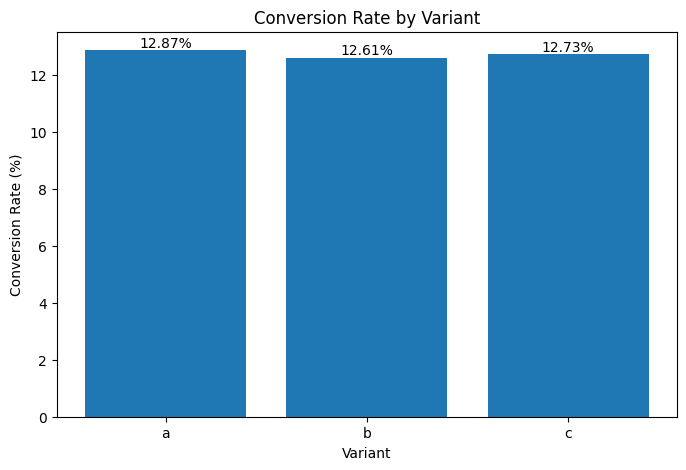

In [ ]:
# ============================================================
# CONVERSION RATE BY VARIANT
# ============================================================

import matplotlib.pyplot as plt

plot_base = variant_summary.copy()

plt.figure(figsize=(8,5))

plt.bar(
    plot_base['variant'],
    plot_base['conversion_rate']
)

plt.title('Conversion Rate by Variant')
plt.xlabel('Variant')
plt.ylabel('Conversion Rate (%)')

for idx, value in enumerate(plot_base['conversion_rate']):
    plt.text(
        idx,
        value,
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
plt.savefig(
    'conversion_rate_by_variant.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

GRÁFICO 2 — Conversion Rate by Flow Type

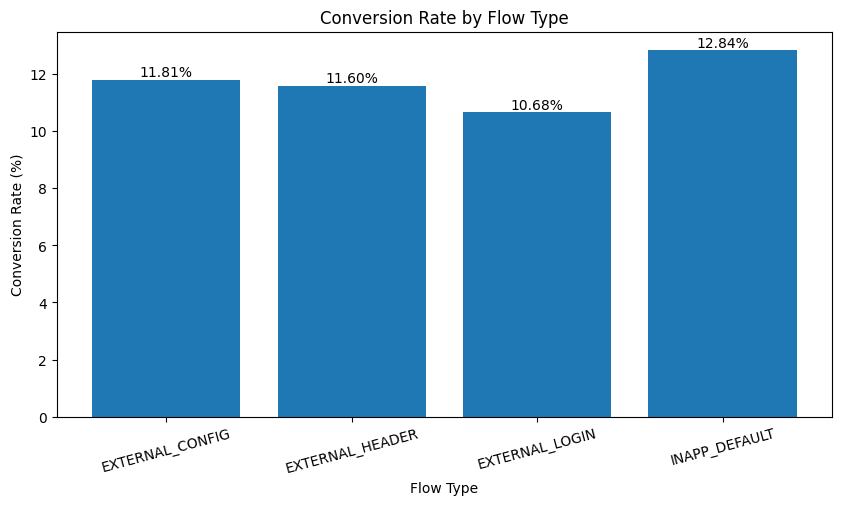

In [ ]:
# ============================================================
# CONVERSION RATE BY FLOW TYPE
# ============================================================

plot_flow_cvr = flow_summary.copy()

plt.figure(figsize=(10,5))

plt.bar(
    plot_flow_cvr['flow_type'],
    plot_flow_cvr['conversion_rate']
)

plt.title('Conversion Rate by Flow Type')
plt.xlabel('Flow Type')
plt.ylabel('Conversion Rate (%)')

for idx, value in enumerate(plot_flow_cvr['conversion_rate']):
    plt.text(
        idx,
        value,
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=15)

plt.show()

In [ ]:
plt.savefig(
    'conversion_rate_by_flow_type.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

GRÁFICO 3 — Adoption vs Conversion

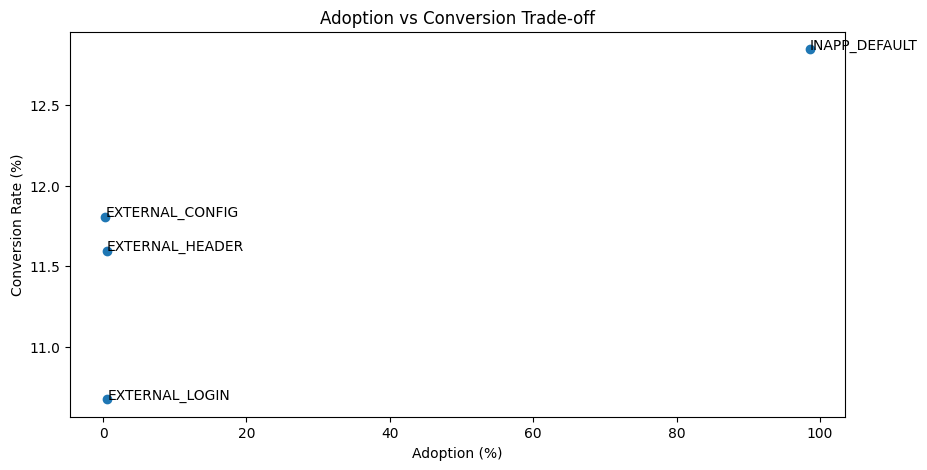

In [ ]:
# ============================================================
# ADOPTION VS CONVERSION TRADE-OFF
# ============================================================

plot_tradeoff = flow_summary.copy()

plot_tradeoff['adoption_pct'] = (
    plot_tradeoff['visits']
    /
    plot_tradeoff['visits'].sum()
) * 100

plt.figure(figsize=(10,5))

plt.scatter(
    plot_tradeoff['adoption_pct'],
    plot_tradeoff['conversion_rate']
)

for idx, row in plot_tradeoff.iterrows():
    plt.text(
        row['adoption_pct'],
        row['conversion_rate'],
        row['flow_type']
    )

plt.xlabel('Adoption (%)')
plt.ylabel('Conversion Rate (%)')

plt.title('Adoption vs Conversion Trade-off')

plt.show()

In [ ]:
plt.savefig(
    'adoption_vs_conversion_tradeoff.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>